The business challenge involves a company that wants to analyze performance gaps between its departments by exploring the relationships between qualitative variables (department, satisfaction) and quantitative variables (performance scores, hours worked).
We will perform several statistical tests.

### I. Basic Import

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import pandas as pd

### II. Dataset Loading and its Structure

In [2]:
path = 'Extended_Employee_Performance_and_Productivity_Data.csv'
#data_str = np.loadtxt(path, delimiter=',', dtype=str, skiprows=0)
data_gen = np.genfromtxt(path, delimiter=',', dtype=None, names=True)

In [4]:
#data_str.shape

In [3]:
data_gen.shape

(100000,)

In [4]:
print(data_gen.dtype.names)

('Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned')


In [5]:
data_gen['Projects_Handled'][0]

np.int64(32)

In [6]:
data_gen['Department']

array(['IT', 'Finance', 'Finance', ..., 'Operations', 'HR', 'Finance'],
      shape=(100000,), dtype='<U16')

In this dataset, there are 20 columns and 100 000 rows.

### III. Univariate Analysis

I will present an univariate analysis only for Employee_Satisfaction_Score which is of numerical type.

In [7]:
employee_satisfaction_score = data_gen['Employee_Satisfaction_Score']

In [8]:
employee_satisfaction_score.shape

(100000,)

In [9]:
np.mean(employee_satisfaction_score), np.median(employee_satisfaction_score), np.std(employee_satisfaction_score)

(np.float64(2.9990883999999998),
 np.float64(3.0),
 np.float64(1.1507136589896898))

In [10]:
np.min(employee_satisfaction_score), np.max(employee_satisfaction_score)

(np.float64(1.0), np.float64(5.0))

In [11]:
vals, counts = np.unique(employee_satisfaction_score, return_counts=True)
modes = vals[counts == counts.max()]
modes, counts.max()

(array([2.32]), np.int64(302))

In [12]:
employee_satisfaction_score = employee_satisfaction_score[~np.isnan(employee_satisfaction_score)]
q1, q3 = np.quantile(employee_satisfaction_score, [0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_mask = (employee_satisfaction_score < lower_bound) | (employee_satisfaction_score > upper_bound)
n_outliers = np.sum(outliers_mask)
n_total = employee_satisfaction_score.shape[0]
print(f'Number of outliers: {n_outliers}')
print(f'Percentage of outliers: {n_outliers / n_total:.2%}')

Number of outliers: 0
Percentage of outliers: 0.00%


Text(0, 0.5, 'Frequency')

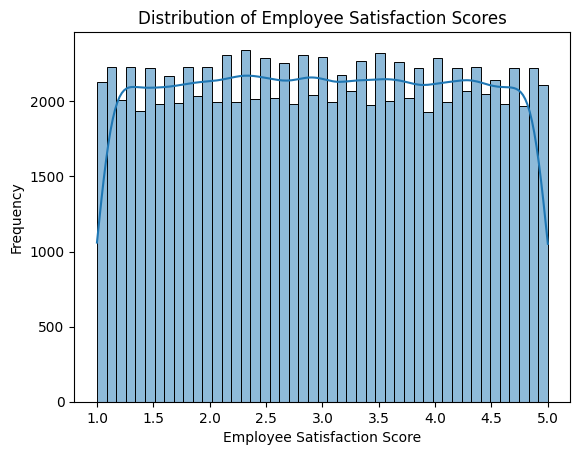

In [13]:
sns.histplot(employee_satisfaction_score, kde=True)
plt.title('Distribution of Employee Satisfaction Scores')   
plt.xlabel('Employee Satisfaction Score')
plt.ylabel('Frequency')

In [15]:
skewness = stats.skew(employee_satisfaction_score)
kurtosis = stats.kurtosis(employee_satisfaction_score, fisher=False)
excess_kurtosis = stats.kurtosis(employee_satisfaction_score, fisher=True)
skewness, kurtosis, excess_kurtosis

(np.float64(0.0013210386966716673),
 np.float64(1.809045133309011),
 np.float64(-1.190954866690989))

According to the shape of the Employee_Satisfaction_Score distribution, it seems not possible to have a normal distribution. Moreover the normal skewness is 0 and the normal curtosis is 3 while here we have 1.809 as curtosis value.

Text(0, 0.5, 'Ordered Values')

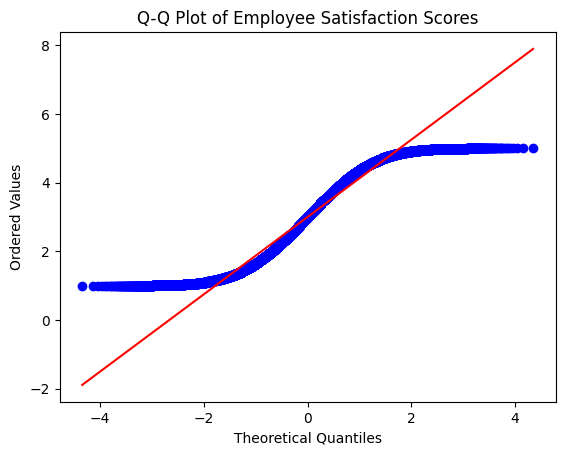

In [16]:
plt.figure()
stats.probplot(employee_satisfaction_score, plot=plt)
plt.title('Q-Q Plot of Employee Satisfaction Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

We have several data points that deviate from the norm; they do not lie on the straight line.

In [17]:
shapiro_stat, shapiro_p = stats.shapiro(employee_satisfaction_score)
shapiro_stat, shapiro_p

c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


(np.float64(0.955892068107166), np.float64(5.484692543203088e-91))

In [18]:
ks_stat, ks_p = stats.kstest(employee_satisfaction_score, 'norm', 
                             args=(np.mean(employee_satisfaction_score), np.std(employee_satisfaction_score)))
ks_stat, ks_p

(np.float64(0.05821721753719333), np.float64(4.749618267731029e-295))

In [19]:
ad_result = stats.anderson(employee_satisfaction_score, dist='norm', method='interpolate')
ad_result.pvalue

np.float64(0.01)

In [20]:
stat_lillie, p_lillie = lilliefors(employee_satisfaction_score, dist='norm')
stat_lillie, p_lillie

(np.float64(0.0582160421609943), np.float64(0.0009999999999998899))

In [21]:
stat_dagostino, p_dagostino = stats.normaltest(employee_satisfaction_score)
stat_dagostino, p_dagostino

(np.float64(81651.05604531566), np.float64(0.0))

All statistical tests give the same results: non-normal distribution for Employee_Satisfaction_Score.

### IV. Bivariate Analysis and statistical Tests

#### 1. About Performance Score

In [22]:
performance_score = data_gen['Performance_Score']

In [23]:
monthly_salary = data_gen['Monthly_Salary']

In [24]:
team_size = data_gen['Team_Size']

In [25]:
department = data_gen['Department']

In [41]:
gender = data_gen['Gender']

Data are loaded for all interesting variables that we want to study.

In [26]:
type(performance_score[0]), type(monthly_salary[0]), type(team_size[0]), type(department[0])

(numpy.int64, numpy.float64, numpy.int64, numpy.str_)

In [27]:
groups = np.unique(performance_score)
groups

array([1, 2, 3, 4, 5])

There are 5 groups of Performance_Score whose scores 1, 2, 3, 4, 5

<Axes: xlabel='col_0', ylabel='row_0'>

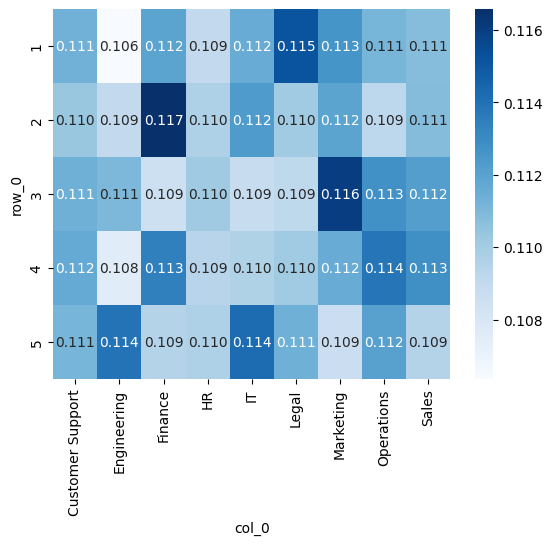

In [39]:
table = pd.crosstab(performance_score, department, normalize='index')
sns.heatmap(table, annot=True, fmt='.3f', cmap='Blues')

In [44]:
table = pd.crosstab(performance_score, department)
chi2_stat, p_value, dof, expected = stats.chi2_contingency(table)
chi2_stat, p_value, dof

(np.float64(29.840143671201673), np.float64(0.5762765037057908), 32)

<Axes: xlabel='col_0', ylabel='row_0'>

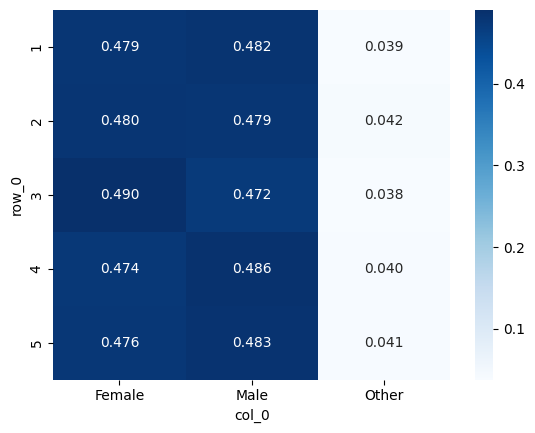

In [45]:
table = pd.crosstab(performance_score, gender, normalize='index')
sns.heatmap(table, annot=True, fmt='.3f', cmap='Blues')

In [49]:
table = pd.crosstab(performance_score, gender)
chi2_stat, p_value, dof, expected = stats.chi2_contingency(table)
chi2_stat, p_value, dof

(np.float64(15.673410089379828), np.float64(0.047300419587846046), 8)

According to Chi-2 test there is no association between Performance_Score and Department variables.

According to Chi-2 test there is an association between Performance_Score and Gender variables. Now, we are going to measure the strength of this association through Cramér's V and Tschruprow's T

In [53]:
cramer_v = stats.contingency.association(table, method="cramer")
tschuprow_t = stats.contingency.association(table, method="tschuprow")
cramer_v, tschuprow_t

(0.008852516616584188, 0.007444049488859584)

According to these values, the association intensity between Performance_Score and Gender is negligible.

In [54]:
salary_groups = [monthly_salary[performance_score == g] for g in groups]
salary_groups

[array([6050., 4400., 5500., ..., 6600., 6600., 4400.], shape=(20120,)),
 array([4800., 4800., 7200., ..., 7200., 4200., 4800.], shape=(20013,)),
 array([5850., 7800., 7800., ..., 7800., 5200., 7800.], shape=(19999,)),
 array([4900., 5600., 6300., ..., 7700., 4900., 4900.], shape=(19940,)),
 array([6750., 7500., 5250., ..., 8250., 8250., 8250.], shape=(19928,))]

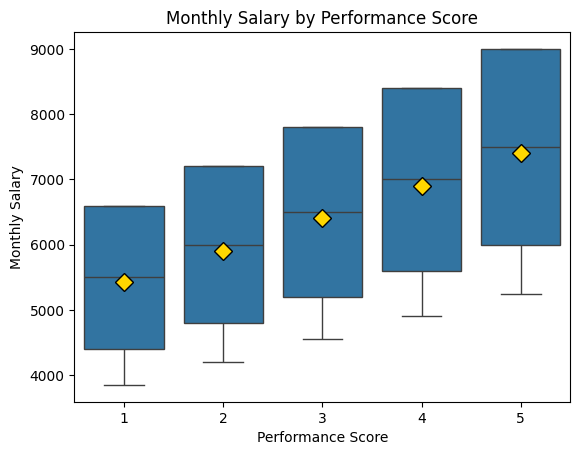

In [55]:
plt.figure()
sns.boxplot(x=performance_score, y=monthly_salary,
            showmeans=True,
            meanprops={'marker': 'D',     # Losange
                            'markerfacecolor': 'gold',
                            'markeredgecolor': 'black',
                            'markersize': 9})
plt.title('Monthly Salary by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Monthly Salary')
plt.show()

In [56]:
h_stat_salary, p_value_salary = stats.kruskal(*salary_groups)
h_stat_salary, p_value_salary

(np.float64(22833.24209957118), np.float64(0.0))

With Kruskal-Wallis test, there is significant differences between Monthly_Salary in the groups of Performance_Score.

In [57]:
team_size_groups = [team_size[performance_score == g] for g in groups]
team_size_groups

[array([ 4, 13,  1, ..., 14,  5, 13], shape=(20120,)),
 array([10, 15,  7, ..., 13, 13,  5], shape=(20013,)),
 array([10, 15,  4, ..., 18, 10,  5], shape=(19999,)),
 array([ 7,  4, 13, ..., 17,  1, 16], shape=(19940,)),
 array([14, 12, 16, ..., 12, 10,  2], shape=(19928,))]

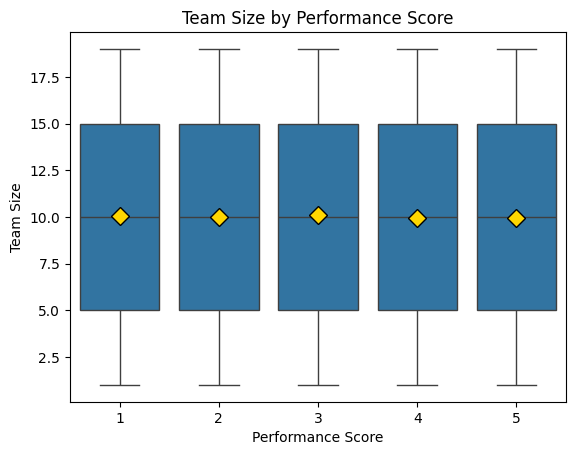

In [58]:
plt.figure()
sns.boxplot(x=performance_score, y=team_size,
            showmeans=True,
            meanprops={'marker': 'D',     # Losange
                            'markerfacecolor': 'gold',
                            'markeredgecolor': 'black',
                            'markersize': 9})
plt.title('Team Size by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Team Size')
plt.show()

In [59]:
h_stat_team_size, p_value_team_size = stats.kruskal(*team_size_groups)
h_stat_team_size, p_value_team_size

(np.float64(11.121527091582234), np.float64(0.02523163901664782))

With Kruskal-Wallis test, there is significant differences between Team_Size in the groups of Performance_Score.

Since there are 5 different groups, we want to perform ANOVA (parametric test) but we have to check its hypothesis.

In [60]:
stat_levene, p_levene = stats.levene(*team_size_groups, center='median')
stat_levene, p_levene

(np.float64(1.3347580347415746), np.float64(0.25425340435382277))

In [61]:
stat_levene, p_levene = stats.levene(*salary_groups, center='median')
stat_levene, p_levene

(np.float64(881.5843849092894), np.float64(0.0))

With Levene test, we can conclude there are equal variance between the different groups of Team_Size for Performance_Score.

With Levene test, we can conclude there are'nt equal variance between the different groups of Monthly_Salary for Performance_Score; so it is useless to perform ANOVA.

We will continue normality tests only for the groups of Team_Size for Performance_Score.

In [62]:
for g in groups:
    x = team_size[performance_score == g]
    
    stat_sh, p_sh = stats.shapiro(x)
    stat_ks, p_ks = stats.kstest(x, 'norm', args=(np.mean(x), np.std(x)))
    ad_result = stats.anderson(x, dist='norm', method='interpolate')
    stat_lillie, p_lillie = lilliefors(x, dist='norm')
    stat_dagostino, p_dagostino = stats.normaltest(x)

    print("Group : ", g, p_sh)
    print("Group : ", g, p_ks)
    print("Group : ", g, ad_result.pvalue)
    print("Group : ", g, p_lillie)
    print("Group : ", g, p_dagostino)

c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20120.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20013.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19999.
  res = hypotest_fun_out(*samples, **kwds)


Group :  1 8.738852368398584e-63
Group :  1 5.665248769505893e-119
Group :  1 0.01
Group :  1 0.0009999999999998899
Group :  1 0.0
Group :  2 8.841773296296151e-63
Group :  2 3.6529420535490656e-122
Group :  2 0.01
Group :  2 0.0009999999999998899
Group :  2 0.0
Group :  3 4.3519871429112757e-63
Group :  3 1.0335807986209088e-130
Group :  3 0.01
Group :  3 0.0009999999999998899
Group :  3 0.0
Group :  4 2.641406364837548e-63
Group :  4 1.146353764503936e-130
Group :  4 0.01
Group :  4 0.0009999999999998899
Group :  4 0.0
Group :  5 2.538332878289558e-63
Group :  5 1.5624803742563347e-133
Group :  5 0.01
Group :  5 0.0009999999999998899
Group :  5 0.0


c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19940.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19928.
  res = hypotest_fun_out(*samples, **kwds)


According to all normality tests, there is no normality for the groups of Team_Size for Performance_Score.

Therefore, it is not necessary to perform ANOVA for the groups of Team_Size for Performance_Score.

#### 2. About Employee Satisfaction Score

In [64]:
employee_satisfaction_score = data_gen['Employee_Satisfaction_Score']
employee_satisfaction_score = employee_satisfaction_score[~np.isnan(employee_satisfaction_score)]   

In [66]:
groups = np.unique(department)
groups

array(['Customer Support', 'Engineering', 'Finance', 'HR', 'IT', 'Legal',
       'Marketing', 'Operations', 'Sales'], dtype='<U16')

In [67]:
employee_satisfaction_score_groups = [employee_satisfaction_score[department == g] for g in groups]
employee_satisfaction_score_groups

[array([1.86, 2.34, 1.96, ..., 3.74, 3.9 , 2.13], shape=(11116,)),
 array([1.25, 2.09, 2.93, ..., 3.16, 4.48, 1.48], shape=(10956,)),
 array([1.72, 3.17, 2.22, ..., 1.34, 1.28, 2.64], shape=(11200,)),
 array([2.13, 4.43, 4.21, ..., 4.73, 1.33, 3.1 ], shape=(10960,)),
 array([2.63, 2.77, 4.46, ..., 2.66, 4.01, 3.48], shape=(11131,)),
 array([1.35, 1.95, 2.9 , ..., 2.44, 2.83, 4.21], shape=(11118,)),
 array([1.44, 1.94, 4.84, ..., 2.11, 4.2 , 1.25], shape=(11216,)),
 array([3.15, 3.7 , 4.84, ..., 2.84, 1.04, 2.6 ], shape=(11181,)),
 array([1.19, 4.66, 4.26, ..., 2.55, 3.27, 3.22], shape=(11122,))]

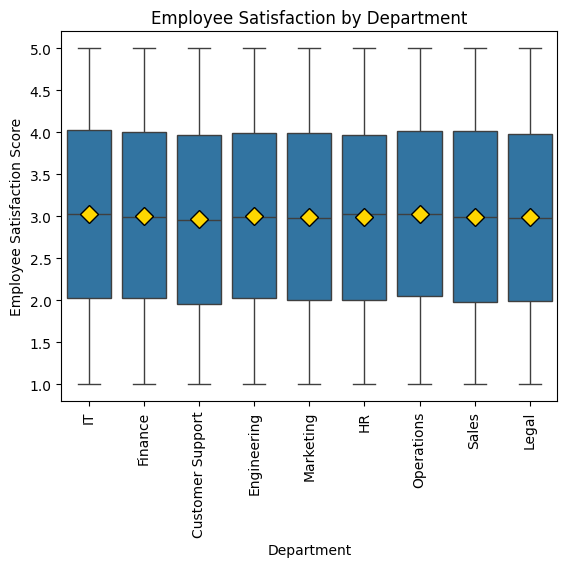

In [69]:
plt.figure()
sns.boxplot(x=department, y=employee_satisfaction_score,
            showmeans=True,
            meanprops={'marker': 'D',     # Losange
                            'markerfacecolor': 'gold',
                            'markeredgecolor': 'black',
                            'markersize': 9})
plt.title('Employee Satisfaction by Department')
plt.xlabel('Department')
plt.ylabel('Employee Satisfaction Score')
plt.xticks(rotation=90, ha='center')
plt.show()

In [70]:
h_stat_employee_satisfaction, p_value_employee_satisfaction = stats.kruskal(*employee_satisfaction_score_groups)
h_stat_employee_satisfaction, p_value_employee_satisfaction

(np.float64(21.639125082958255), np.float64(0.005630134221544436))

With Kruskal-Wallis test, there is significant differences between Employee_Satisfaction_Score in the groups of Department.

Since there are 9 groups in Department, we will perform ANOVA (parametric test) too.

In [71]:
for g in groups:
    x = employee_satisfaction_score[department == g]
    
    stat_sh, p_sh = stats.shapiro(x)
    stat_ks, p_ks = stats.kstest(x, 'norm', args=(np.mean(x), np.std(x)))
    ad_result = stats.anderson(x, dist='norm', method='interpolate')
    stat_lillie, p_lillie = lilliefors(x, dist='norm')
    stat_dagostino, p_dagostino = stats.normaltest(x)

    print("Group : ", g, p_sh)
    print("Group : ", g, p_ks)
    print("Group : ", g, ad_result.pvalue)
    print("Group : ", g, p_lillie)
    print("Group : ", g, p_dagostino)

c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11116.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10956.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11200.
  res = hypotest_fun_out(*samples, **kwds)


Group :  Customer Support 1.1319826041513752e-49
Group :  Customer Support 2.5677172436279753e-35
Group :  Customer Support 0.01
Group :  Customer Support 0.0009999999999998899
Group :  Customer Support 0.0
Group :  Engineering 8.793722180945027e-49
Group :  Engineering 6.494365823213354e-34
Group :  Engineering 0.01
Group :  Engineering 0.0009999999999998899
Group :  Engineering 0.0
Group :  Finance 1.8790453132163302e-49
Group :  Finance 5.972330272892558e-36
Group :  Finance 0.01
Group :  Finance 0.0009999999999998899
Group :  Finance 0.0


c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10960.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11131.
  res = hypotest_fun_out(*samples, **kwds)


Group :  HR 5.659016931374497e-49
Group :  HR 1.8818139346043506e-33
Group :  HR 0.01
Group :  HR 0.0009999999999998899
Group :  HR 0.0
Group :  IT 1.554281247085069e-49
Group :  IT 3.338498836406615e-37
Group :  IT 0.01
Group :  IT 0.0009999999999998899
Group :  IT 0.0
Group :  Legal 2.7792327203138273e-49
Group :  Legal 1.0639835988765095e-33
Group :  Legal 0.01
Group :  Legal 0.0009999999999998899
Group :  Legal 0.0


c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11118.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11216.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11181.
  res = hypotest_fun_out(*samples, **kwds)


Group :  Marketing 3.2908050913664454e-49
Group :  Marketing 5.689434361134141e-33
Group :  Marketing 0.01
Group :  Marketing 0.0009999999999998899
Group :  Marketing 0.0
Group :  Operations 4.670315790820594e-49
Group :  Operations 9.377967964608339e-33
Group :  Operations 0.01
Group :  Operations 0.0009999999999998899
Group :  Operations 0.0
Group :  Sales 2.891277402459987e-50
Group :  Sales 7.391404780551826e-37
Group :  Sales 0.01
Group :  Sales 0.0009999999999998899
Group :  Sales 0.0


c:\Users\tapib\OneDrive\Desktop\Will\w_Data\data_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11122.
  res = hypotest_fun_out(*samples, **kwds)


According to all normality tests, there is no normality for the groups of Department for Employee_Satisfaction_Score.

Therefore, it is not necessary to perform ANOVA for the groups of Department for Employee_Satisfaction_Score.